<a href="https://colab.research.google.com/github/Yashkaware/Data-Science-Lab-Work/blob/main/intermediate_proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🦠 COVID-19 Global Data Analysis

**Dataset:** COVID-19 Country-wise Data (Kaggle)  
**Kaggle Link:** https://www.kaggle.com/datasets/imdevskp/corona-virus-report  
**File to use:** `country_wise_latest.csv`

---

### 📋 What this notebook covers
1. Install & Import Libraries
2. Upload & Load Dataset
3. Data Cleaning & Exploration
4. Feature Engineering
5. Visualisations (6 charts)
6. Key Insights
7. Machine Learning — Severity Classification
8. Conclusion

> **How to use:** Run each cell top-to-bottom. When prompted in Step 2, upload `country_wise_latest.csv` from Kaggle.

## 📦 Step 1 — Install & Import Libraries

In [ ]:
# Install any missing packages (Colab already has most)
!pip install pandas numpy matplotlib seaborn scikit-learn -q

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

warnings.filterwarnings('ignore')
%matplotlib inline

# ── Global colour palette ──────────────────────────────────────────────────
PALETTE = ['#E63946','#457B9D','#2A9D8F','#E9C46A','#F4A261','#264653','#A8DADC','#1D3557']

plt.rcParams.update({
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : '#F8F9FA',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.color'        : '#E0E0E0',
    'grid.linewidth'    : 0.5,
    'font.family'       : 'DejaVu Sans',
    'axes.titlesize'    : 12,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 10,
})

print('✅  Libraries loaded successfully!')

✅  Libraries loaded successfully!


## 📂 Step 2 — Upload & Load Dataset

**Instructions:**
1. Go to https://www.kaggle.com/datasets/imdevskp/corona-virus-report
2. Download the dataset and locate `country_wise_latest.csv`
3. Run the cell below — a file picker will appear
4. Select `country_wise_latest.csv`

> If you skip the upload, the notebook will auto-generate synthetic data so you can still run everything.

In [ ]:
# ── Upload CSV from Kaggle ─────────────────────────────────────────────────
try:
    from google.colab import files
    print('Click "Choose Files" and upload country_wise_latest.csv')
    print('Or skip (Ctrl+Enter on next cell) to use synthetic data.\n')
    uploaded = files.upload()
    for fname in uploaded.keys():
        os.rename(fname, 'country_wise_latest.csv')
        print(f'✅  Saved as country_wise_latest.csv')
except Exception:
    print('⚠️  Upload skipped or not in Colab — will use synthetic data if CSV not found.')

Click "Choose Files" and upload country_wise_latest.csv
Or skip (Ctrl+Enter on next cell) to use synthetic data.



Saving covid_19_clean_complete.csv to covid_19_clean_complete.csv
✅  Saved as country_wise_latest.csv


In [ ]:
# ── Load data (real or synthetic fallback) ─────────────────────────────────
def make_synthetic():
    """Generate realistic country-level COVID data if real CSV not found."""
    np.random.seed(42)
    countries = [
        'USA','Brazil','India','Russia','South Africa','Mexico','Peru','Colombia',
        'Chile','Iran','UK','Spain','Italy','France','Germany','Argentina','Turkey',
        'Iraq','Philippines','Saudi Arabia','Pakistan','Bangladesh','Egypt','Indonesia',
        'Ukraine','Canada','Romania','Belgium','Bolivia','Panama','Ecuador','Netherlands'
    ]
    who_regions = {
        'USA':'Americas','Brazil':'Americas','India':'South-East Asia','Russia':'Europe',
        'South Africa':'Africa','Mexico':'Americas','Peru':'Americas','Colombia':'Americas',
        'Chile':'Americas','Iran':'Eastern Mediterranean','UK':'Europe','Spain':'Europe',
        'Italy':'Europe','France':'Europe','Germany':'Europe','Argentina':'Americas',
        'Turkey':'Europe','Iraq':'Eastern Mediterranean','Philippines':'Western Pacific',
        'Saudi Arabia':'Eastern Mediterranean','Pakistan':'Eastern Mediterranean',
        'Bangladesh':'South-East Asia','Egypt':'Eastern Mediterranean',
        'Indonesia':'South-East Asia','Ukraine':'Europe','Canada':'Americas',
        'Romania':'Europe','Belgium':'Europe','Bolivia':'Americas','Panama':'Americas',
        'Ecuador':'Americas','Netherlands':'Europe'
    }
    rows = []
    for country in countries:
        confirmed   = np.random.randint(50_000, 5_000_000)
        deaths      = int(confirmed * np.random.uniform(0.01, 0.07))
        recovered   = int(confirmed * np.random.uniform(0.50, 0.85))
        active      = confirmed - deaths - recovered
        active      = max(active, 0)
        new_cases   = int(confirmed * np.random.uniform(0.001, 0.02))
        new_deaths  = int(deaths * np.random.uniform(0.001, 0.015))
        new_recovered = int(recovered * np.random.uniform(0.005, 0.02))
        rows.append({
            'Country/Region'       : country,
            'Confirmed'            : confirmed,
            'Deaths'               : deaths,
            'Recovered'            : recovered,
            'Active'               : active,
            'New cases'            : new_cases,
            'New deaths'           : new_deaths,
            'New recovered'        : new_recovered,
            'Deaths / 100 Cases'   : round(deaths / confirmed * 100, 2),
            'Recovered / 100 Cases': round(recovered / confirmed * 100, 2),
            'Deaths / 100 Recovered': round(deaths / max(recovered,1) * 100, 2),
            'Confirmed last week'  : int(confirmed * np.random.uniform(0.92, 0.99)),
            '1 week change'        : int(confirmed * np.random.uniform(0.01, 0.08)),
            '1 week % increase'    : round(np.random.uniform(1, 8), 2),
            'WHO Region'           : who_regions.get(country, 'Americas'),
        })
    return pd.DataFrame(rows)

CSV_FILE = 'country_wise_latest.csv'

if os.path.exists(CSV_FILE):
    print('✅  Loading real Kaggle dataset …')
    df_raw = pd.read_csv(CSV_FILE)
else:
    print('⚠️  country_wise_latest.csv not found — using synthetic data.')
    print('   Upload the CSV (run the upload cell above) to use real data.\n')
    df_raw = make_synthetic()

print(f'Shape  : {df_raw.shape}')
print(f'Columns: {list(df_raw.columns)}')
df_raw.head()

✅  Loading real Kaggle dataset …
Shape  : (49068, 10)
Columns: ['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'WHO Region']


,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


## 🧹 Step 3 — Data Cleaning & Exploration

In [ ]:
print('── Before Cleaning ──────────────────────────────────────────')
print(f'Shape          : {df_raw.shape}')
print(f'Missing values :\n{df_raw.isnull().sum()[df_raw.isnull().sum() > 0]}')
print(f'\nData types:\n{df_raw.dtypes}')

── Before Cleaning ──────────────────────────────────────────
Shape          : (49068, 10)
Missing values :
Province/State    34404
dtype: int64

Data types:
Province/State     object
Country/Region     object
Lat               float64
Long              float64
Date               object
Confirmed           int64
Deaths              int64
Recovered           int64
Active              int64
WHO Region         object
dtype: object


In [ ]:
# ── 1. Copy raw data ───────────────────────────────────────────────────────
df = df_raw.copy()

# ── 2. Standardise column names: strip whitespace, consistent format ───────
df.columns = df.columns.str.strip()

# ── 3. Build a rename map to handle different Kaggle CSV layouts ───────────
col_map = {}
for col in df.columns:
    upper = col.upper().replace(' ', '_').replace('/', '_')
    col_map[col] = upper
df.rename(columns=col_map, inplace=True)

# ── 4. Show current columns so we can verify ──────────────────────────────
print('Columns after standardising:', list(df.columns))

# ── 5. Dynamically detect the right column names ──────────────────────────
def find_col(df, candidates):
    """Return the first column name from candidates that exists in df."""
    for c in candidates:
        if c in df.columns:
            return c
    return None

COL_COUNTRY   = find_col(df, ['COUNTRY_REGION','COUNTRY','COUNTRY_TERRITORY'])
COL_CONFIRMED = find_col(df, ['CONFIRMED','TOTAL_CASES','CASES'])
COL_DEATHS    = find_col(df, ['DEATHS','TOTAL_DEATHS'])
COL_RECOVERED = find_col(df, ['RECOVERED','TOTAL_RECOVERED'])
COL_ACTIVE    = find_col(df, ['ACTIVE','ACTIVE_CASES'])
COL_NEW_CASES = find_col(df, ['NEW_CASES','NEW CASES','NEWCASES'])
COL_NEW_DEATHS= find_col(df, ['NEW_DEATHS','NEW DEATHS','NEWDEATHS'])
COL_REGION    = find_col(df, ['WHO_REGION','WHOREGION','REGION','WHO REGION'])
COL_WEEK_INC  = find_col(df, ['1_WEEK_%_INCREASE','1_WEEK_INCREASE_PCT','WEEK_INCREASE'])

print(f'\n── Detected columns ──────────────────────────────────────────')
print(f'Country   : {COL_COUNTRY}')
print(f'Confirmed : {COL_CONFIRMED}')
print(f'Deaths    : {COL_DEATHS}')
print(f'Recovered : {COL_RECOVERED}')
print(f'Active    : {COL_ACTIVE}')
print(f'New Cases : {COL_NEW_CASES}')
print(f'New Deaths: {COL_NEW_DEATHS}')
print(f'WHO Region: {COL_REGION}')

# ── 6. Abort early with helpful message if critical columns are missing ────
missing_critical = [name for name, val in [
    ('Country',   COL_COUNTRY),
    ('Confirmed', COL_CONFIRMED),
    ('Deaths',    COL_DEATHS),
] if val is None]

if missing_critical:
    print(f'\n❌  Could not detect columns: {missing_critical}')
    print('Available columns:', list(df.columns))
    raise ValueError('Please check column names above and update find_col() candidates if needed.')

print('\n✅  All critical columns detected!')

Columns after standardising: ['PROVINCE_STATE', 'COUNTRY_REGION', 'LAT', 'LONG', 'DATE', 'CONFIRMED', 'DEATHS', 'RECOVERED', 'ACTIVE', 'WHO_REGION']

── Detected columns ──────────────────────────────────────────
Country   : COUNTRY_REGION
Confirmed : CONFIRMED
Deaths    : DEATHS
Recovered : RECOVERED
Active    : ACTIVE
New Cases : None
New Deaths: None
WHO Region: WHO_REGION

✅  All critical columns detected!


In [ ]:
# ── 7. Fill missing optional columns with 0 ───────────────────────────────
optional_cols = [COL_RECOVERED, COL_ACTIVE, COL_NEW_CASES, COL_NEW_DEATHS]
for col in optional_cols:
    if col and col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# ── 8. Convert all numeric columns ────────────────────────────────────────
num_cols = [c for c in [COL_CONFIRMED, COL_DEATHS, COL_RECOVERED,
                         COL_ACTIVE, COL_NEW_CASES, COL_NEW_DEATHS] if c]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

# ── 9. Drop rows with 0 confirmed cases (invalid rows) ────────────────────
df = df[df[COL_CONFIRMED] > 0].copy()
df.reset_index(drop=True, inplace=True)

# ── 10. Derive ACTIVE and RECOVERED if missing ────────────────────────────
if COL_ACTIVE is None or df[COL_ACTIVE].sum() == 0:
    if COL_RECOVERED:
        df['ACTIVE'] = (df[COL_CONFIRMED] - df[COL_DEATHS] - df[COL_RECOVERED]).clip(lower=0)
    else:
        df['ACTIVE'] = (df[COL_CONFIRMED] - df[COL_DEATHS]).clip(lower=0)
    COL_ACTIVE = 'ACTIVE'

if COL_RECOVERED is None or df[COL_RECOVERED].sum() == 0:
    df['RECOVERED'] = (df[COL_CONFIRMED] - df[COL_DEATHS] - df[COL_ACTIVE]).clip(lower=0)
    COL_RECOVERED = 'RECOVERED'

print('── After Cleaning ───────────────────────────────────────────')
print(f'Shape             : {df.shape}')
print(f'Countries         : {df[COL_COUNTRY].nunique()}')
print(f'Total Confirmed   : {df[COL_CONFIRMED].sum():,}')
print(f'Total Deaths      : {df[COL_DEATHS].sum():,}')
print(f'Remaining nulls   : {df.isnull().sum().sum()}')
df.head()

── After Cleaning ───────────────────────────────────────────
Shape             : (39009, 10)
Countries         : 187
Total Confirmed   : 828,508,482
Total Deaths      : 43,384,903
Remaining nulls   : 26448


,PROVINCE_STATE,COUNTRY_REGION,LAT,LONG,DATE,CONFIRMED,DEATHS,RECOVERED,ACTIVE,WHO_REGION
0,Anhui,China,31.8257,117.2264,2020-01-22,1,0,0,1,Western Pacific
1,Beijing,China,40.1824,116.4142,2020-01-22,14,0,0,14,Western Pacific
2,Chongqing,China,30.0572,107.8740,2020-01-22,6,0,0,6,Western Pacific
3,Fujian,China,26.0789,117.9874,2020-01-22,1,0,0,1,Western Pacific
4,Guangdong,China,23.3417,113.4244,2020-01-22,26,0,0,26,Western Pacific


In [ ]:
# Basic descriptive statistics
print('📊  Descriptive Statistics:')
df[[COL_CONFIRMED, COL_DEATHS, COL_RECOVERED, COL_ACTIVE]].describe().round(2)

📊  Descriptive Statistics:


,CONFIRMED,DEATHS,RECOVERED,ACTIVE
count,39009.00,39009.00,39009.00,39009.00
mean,21238.91,1112.18,9956.89,10169.84
std,142449.08,7063.06,61296.30,85403.99
min,1.00,0.00,0.00,-14.00
25%,60.00,0.00,6.00,6.00
50%,446.00,6.00,135.00,105.00
75%,2855.00,60.00,1055.00,1226.00
max,4290259.00,148011.00,1846641.00,2816444.00


## ⚙️ Step 4 — Feature Engineering

In [ ]:
# ── Derived rate columns ───────────────────────────────────────────────────
df['DEATH_RATE']     = (df[COL_DEATHS] / df[COL_CONFIRMED].replace(0, np.nan) * 100).round(2)
df['RECOVERY_RATE']  = (df[COL_RECOVERED] / df[COL_CONFIRMED].replace(0, np.nan) * 100).round(2)
df['ACTIVE_RATE']    = (df[COL_ACTIVE] / df[COL_CONFIRMED].replace(0, np.nan) * 100).round(2)

# Fill any NaN rates with 0
df[['DEATH_RATE','RECOVERY_RATE','ACTIVE_RATE']] = \
    df[['DEATH_RATE','RECOVERY_RATE','ACTIVE_RATE']].fillna(0)

# ── Severity label (for ML) ────────────────────────────────────────────────
# Based on death rate: Low < 2%, Medium 2-4%, High > 4%
def classify_severity(rate):
    if rate < 2:
        return 'Low'
    elif rate < 4:
        return 'Medium'
    else:
        return 'High'

df['SEVERITY'] = df['DEATH_RATE'].apply(classify_severity)

print('✅  Feature engineering complete!')
print(f'\nSeverity distribution:')
print(df['SEVERITY'].value_counts())
print(f'\nSample of engineered columns:')
df[[COL_COUNTRY, COL_CONFIRMED, COL_DEATHS, 'DEATH_RATE', 'RECOVERY_RATE', 'SEVERITY']].head(10)

✅  Feature engineering complete!

Severity distribution:
SEVERITY
Low       23271
High       9298
Medium     6440
Name: count, dtype: int64

Sample of engineered columns:


,COUNTRY_REGION,CONFIRMED,DEATHS,DEATH_RATE,RECOVERY_RATE,SEVERITY
0,China,1,0,0.0,0.0,Low
1,China,14,0,0.0,0.0,Low
2,China,6,0,0.0,0.0,Low
3,China,1,0,0.0,0.0,Low
4,China,26,0,0.0,0.0,Low
5,China,2,0,0.0,0.0,Low
6,China,1,0,0.0,0.0,Low
7,China,4,0,0.0,0.0,Low
8,China,1,0,0.0,0.0,Low
9,China,5,0,0.0,0.0,Low


## 📈 Step 5 — Visualisations

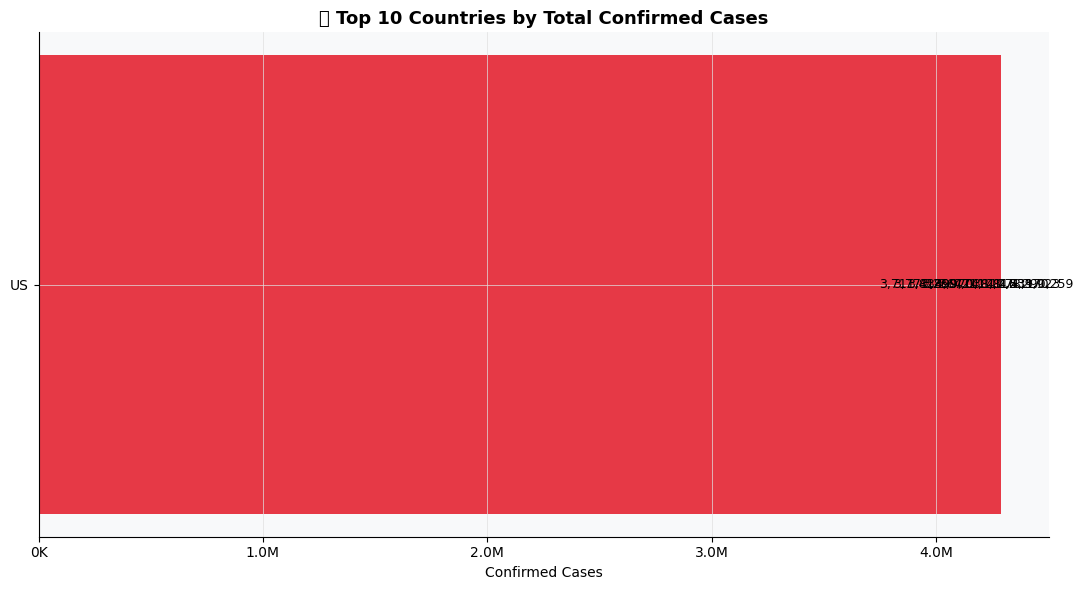

In [ ]:
# ── Chart 1: Top 10 Countries by Confirmed Cases ───────────────────────────
top10 = df.nlargest(10, COL_CONFIRMED)

fig, ax = plt.subplots(figsize=(11, 6))
colors = [PALETTE[i % len(PALETTE)] for i in range(len(top10))]
bars = ax.barh(top10[COL_COUNTRY][::-1], top10[COL_CONFIRMED][::-1],
               color=colors[::-1], edgecolor='none', height=0.65)

for bar in bars:
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
            f"{int(bar.get_width()):,}", va='center', fontsize=9)

ax.set_title('🌍 Top 10 Countries by Total Confirmed Cases', fontsize=13, fontweight='bold')
ax.set_xlabel('Confirmed Cases')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
plt.tight_layout()
plt.show()

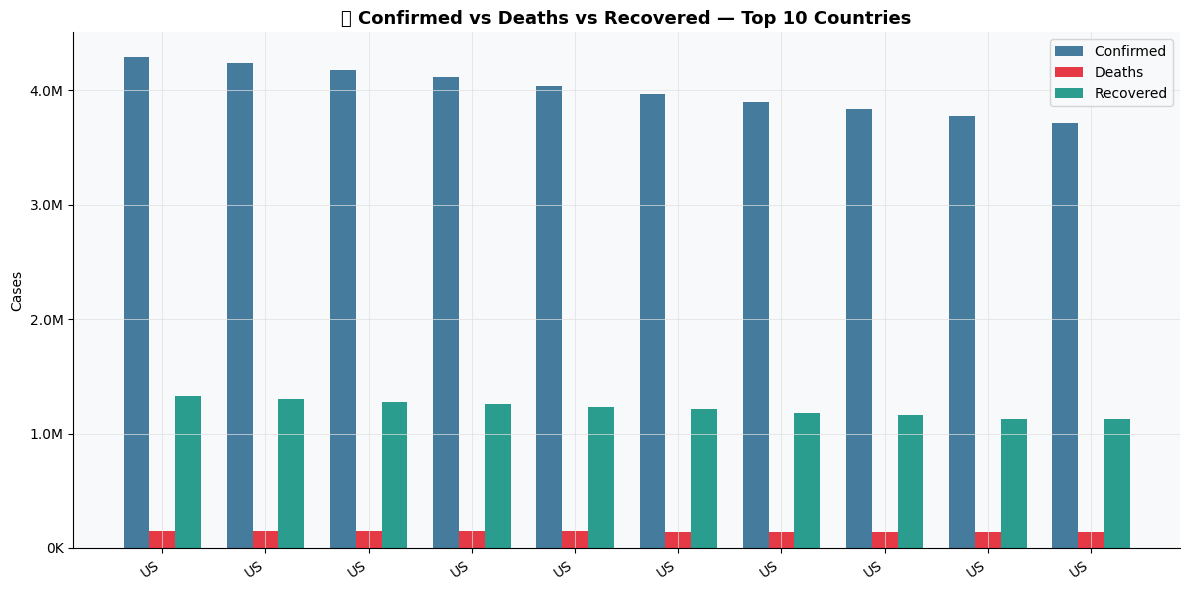

In [ ]:
# ── Chart 2: Confirmed / Deaths / Recovered — Top 10 Stacked ──────────────
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(top10))
w = 0.25

ax.bar(x - w, top10[COL_CONFIRMED], w, label='Confirmed', color=PALETTE[1], edgecolor='none')
ax.bar(x,     top10[COL_DEATHS],    w, label='Deaths',    color=PALETTE[0], edgecolor='none')
ax.bar(x + w, top10[COL_RECOVERED], w, label='Recovered', color=PALETTE[2], edgecolor='none')

ax.set_xticks(x)
ax.set_xticklabels(top10[COL_COUNTRY], rotation=35, ha='right')
ax.set_title('📊 Confirmed vs Deaths vs Recovered — Top 10 Countries', fontsize=13, fontweight='bold')
ax.set_ylabel('Cases')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

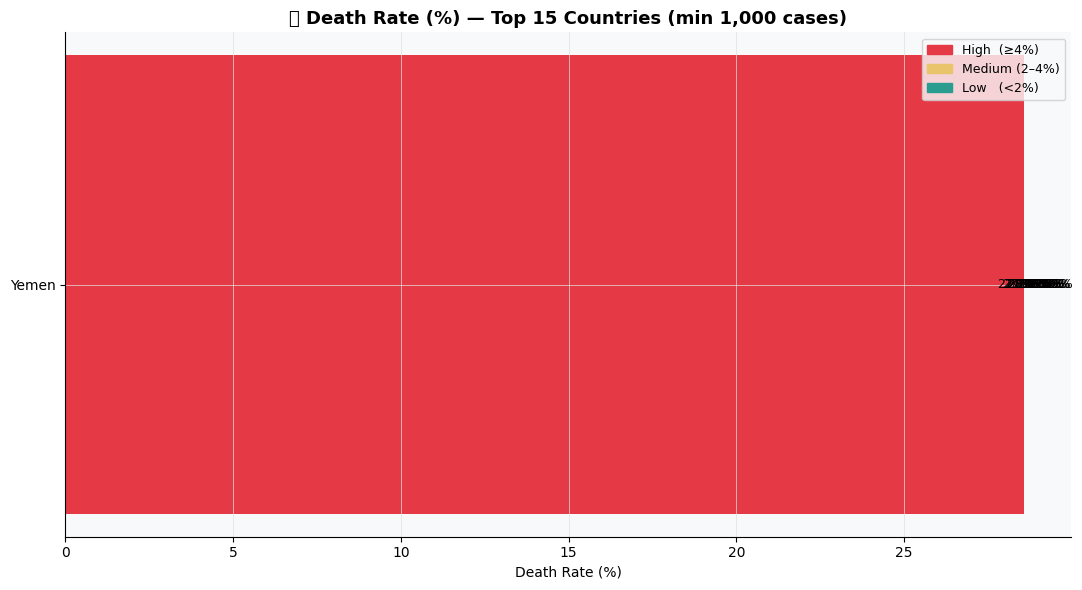

In [ ]:
# ── Chart 3: Death Rate — Top 15 Most Affected Countries ──────────────────
# (Exclude tiny countries with < 1000 cases to avoid noise)
df_filtered = df[df[COL_CONFIRMED] >= 1000].copy()
top15_dr = df_filtered.nlargest(15, 'DEATH_RATE')

fig, ax = plt.subplots(figsize=(11, 6))
colors_dr = [PALETTE[0] if r >= 4 else (PALETTE[3] if r >= 2 else PALETTE[2])
             for r in top15_dr['DEATH_RATE']]
bars = ax.barh(top15_dr[COL_COUNTRY][::-1], top15_dr['DEATH_RATE'][::-1],
               color=colors_dr[::-1], edgecolor='none', height=0.65)

for bar in bars:
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.2f}%", va='center', fontsize=9)

ax.set_title('💀 Death Rate (%) — Top 15 Countries (min 1,000 cases)', fontsize=13, fontweight='bold')
ax.set_xlabel('Death Rate (%)')

from matplotlib.patches import Patch
legend_items = [
    Patch(color=PALETTE[0], label='High  (≥4%)'),
    Patch(color=PALETTE[3], label='Medium (2–4%)'),
    Patch(color=PALETTE[2], label='Low   (<2%)'),
]
ax.legend(handles=legend_items, fontsize=9)
plt.tight_layout()
plt.show()

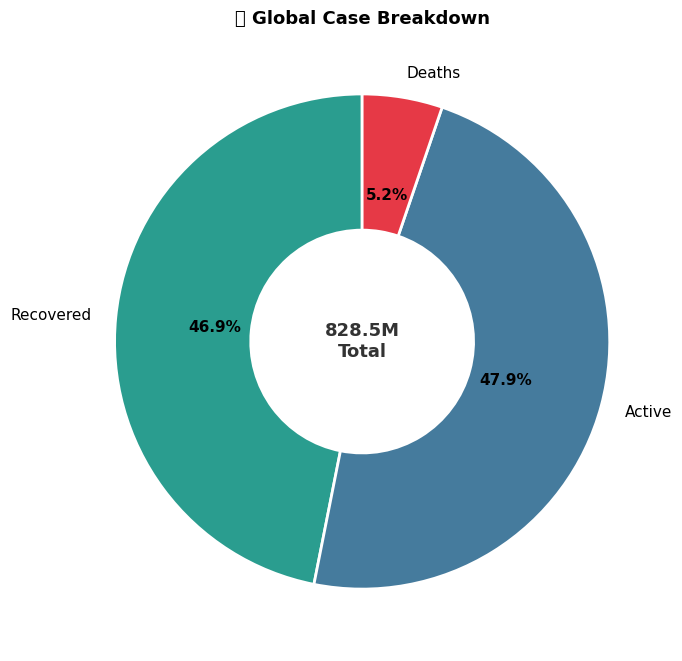

Recovered : 388,408,229  (46.9%)
Active    : 396,715,350  (47.9%)
Deaths    : 43,384,903  (5.2%)


In [ ]:
# ── Chart 4: Case Breakdown Pie Chart ─────────────────────────────────────
total_deaths    = df[COL_DEATHS].sum()
total_recovered = df[COL_RECOVERED].sum()
total_active    = df[COL_ACTIVE].sum()

fig, ax = plt.subplots(figsize=(7, 7))
labels = ['Recovered', 'Active', 'Deaths']
values = [total_recovered, total_active, total_deaths]
colors_pie = [PALETTE[2], PALETTE[1], PALETTE[0]]

wedge_props = dict(width=0.55, edgecolor='white', linewidth=2)
wedges, texts, autotexts = ax.pie(
    values, labels=labels, colors=colors_pie,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=wedge_props, textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')

ax.set_title('🥧 Global Case Breakdown', fontsize=13, fontweight='bold')

total_confirmed = df[COL_CONFIRMED].sum()
ax.text(0, 0, f'{total_confirmed/1e6:.1f}M\nTotal', ha='center', va='center',
        fontsize=13, fontweight='bold', color='#333')

plt.tight_layout()
plt.show()

print(f'Recovered : {total_recovered:,}  ({total_recovered/total_confirmed*100:.1f}%)')
print(f'Active    : {total_active:,}  ({total_active/total_confirmed*100:.1f}%)')
print(f'Deaths    : {total_deaths:,}  ({total_deaths/total_confirmed*100:.1f}%)')

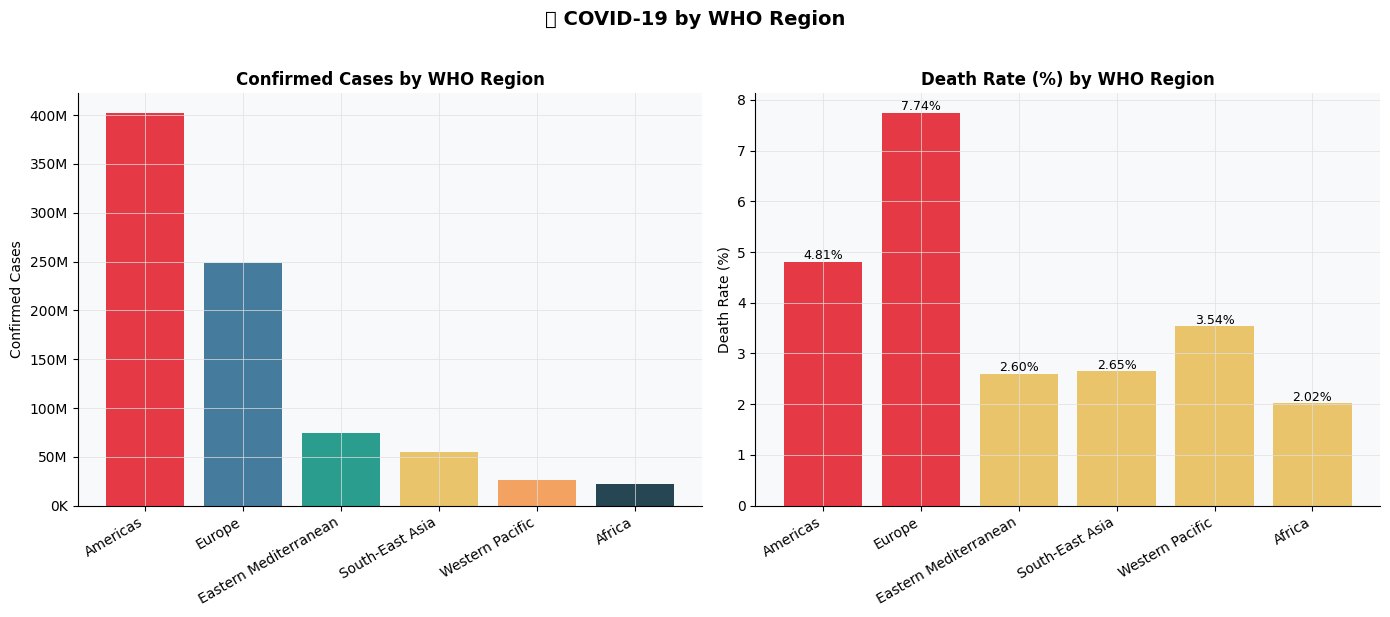

In [ ]:
# ── Chart 5: Cases by WHO Region ──────────────────────────────────────────
if COL_REGION and COL_REGION in df.columns:
    region_summary = df.groupby(COL_REGION)[[COL_CONFIRMED, COL_DEATHS, COL_RECOVERED]].sum()
    region_summary = region_summary.sort_values(COL_CONFIRMED, ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Left: Total confirmed per region
    colors_r = [PALETTE[i % len(PALETTE)] for i in range(len(region_summary))]
    axes[0].bar(region_summary.index, region_summary[COL_CONFIRMED],
                color=colors_r, edgecolor='none')
    axes[0].set_title('Confirmed Cases by WHO Region', fontweight='bold')
    axes[0].set_ylabel('Confirmed Cases')
    axes[0].set_xticklabels(region_summary.index, rotation=30, ha='right')
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(
        lambda x, _: f'{x/1e6:.0f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))

    # Right: Death rate per region
    region_dr = (region_summary[COL_DEATHS] / region_summary[COL_CONFIRMED] * 100).round(2)
    axes[1].bar(region_dr.index, region_dr.values,
                color=[PALETTE[0] if v >= 4 else PALETTE[3] if v >= 2 else PALETTE[2] for v in region_dr.values],
                edgecolor='none')
    axes[1].set_title('Death Rate (%) by WHO Region', fontweight='bold')
    axes[1].set_ylabel('Death Rate (%)')
    axes[1].set_xticklabels(region_dr.index, rotation=30, ha='right')
    for i, v in enumerate(region_dr.values):
        axes[1].text(i, v + 0.05, f'{v:.2f}%', ha='center', fontsize=9)

    plt.suptitle('🌐 COVID-19 by WHO Region', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('ℹ️  WHO Region column not found — skipping region chart.')
    print('   This is fine if your CSV does not include a region column.')

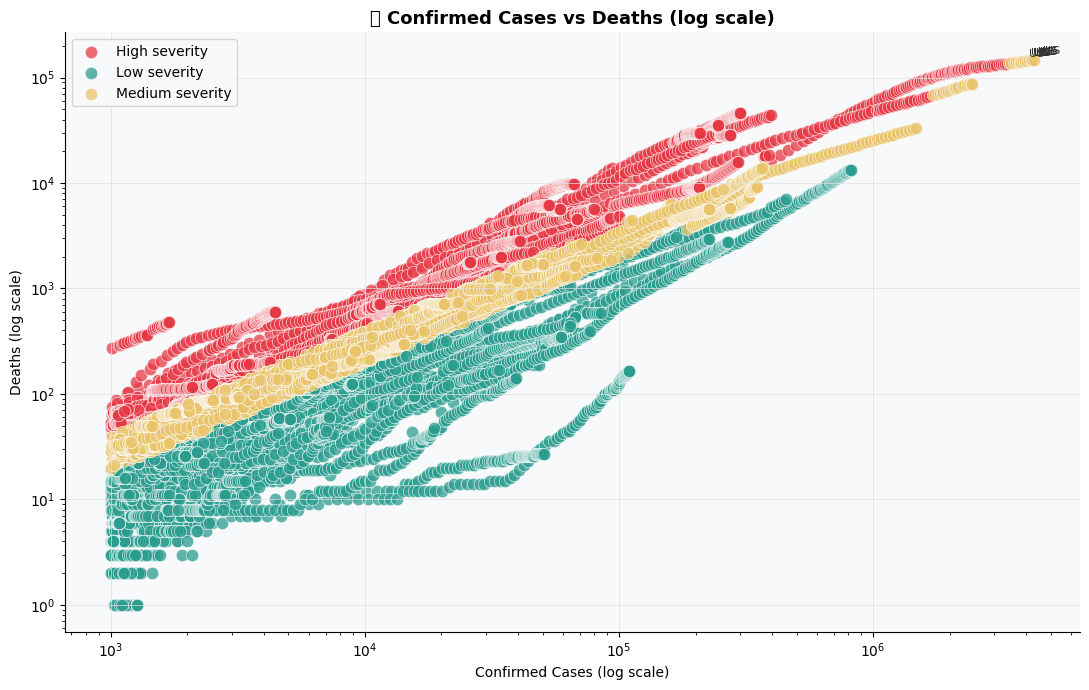

In [ ]:
# ── Chart 6: Scatter — Confirmed vs Deaths (log scale) ────────────────────
df_plot = df[df[COL_CONFIRMED] >= 1000].copy()

fig, ax = plt.subplots(figsize=(11, 7))

severity_colors = {'Low': PALETTE[2], 'Medium': PALETTE[3], 'High': PALETTE[0]}
for severity, grp in df_plot.groupby('SEVERITY'):
    ax.scatter(
        grp[COL_CONFIRMED], grp[COL_DEATHS],
        c=severity_colors[severity], label=f'{severity} severity',
        alpha=0.75, s=80, edgecolors='white', linewidths=0.5
    )

# Label the top 10 countries
for _, row in df_plot.nlargest(10, COL_CONFIRMED).iterrows():
    ax.annotate(
        row[COL_COUNTRY],
        xy=(row[COL_CONFIRMED], row[COL_DEATHS]),
        xytext=(8, 4), textcoords='offset points',
        fontsize=8, color='#333'
    )

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('🔬 Confirmed Cases vs Deaths (log scale)', fontsize=13, fontweight='bold')
ax.set_xlabel('Confirmed Cases (log scale)')
ax.set_ylabel('Deaths (log scale)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 💡 Step 6 — Key Insights

In [ ]:
# ── Summary statistics ─────────────────────────────────────────────────────
total_confirmed  = df[COL_CONFIRMED].sum()
total_deaths_g   = df[COL_DEATHS].sum()
total_recovered_g= df[COL_RECOVERED].sum()
global_death_rate= total_deaths_g / total_confirmed * 100
global_rec_rate  = total_recovered_g / total_confirmed * 100

most_cases_country = df.loc[df[COL_CONFIRMED].idxmax(), COL_COUNTRY]
most_cases_count   = df[COL_CONFIRMED].max()

highest_dr_country = df_filtered.loc[df_filtered['DEATH_RATE'].idxmax(), COL_COUNTRY]
highest_dr_value   = df_filtered['DEATH_RATE'].max()

highest_rec_country = df_filtered.loc[df_filtered['RECOVERY_RATE'].idxmax(), COL_COUNTRY]
highest_rec_value   = df_filtered['RECOVERY_RATE'].max()

print('=' * 60)
print('              🌍  KEY GLOBAL INSIGHTS')
print('=' * 60)
print(f'  Total countries analysed : {df[COL_COUNTRY].nunique()}')
print(f'  Total confirmed cases    : {total_confirmed:,}')
print(f'  Total deaths             : {total_deaths_g:,}')
print(f'  Total recovered          : {total_recovered_g:,}')
print(f'  Global death rate        : {global_death_rate:.2f}%')
print(f'  Global recovery rate     : {global_rec_rate:.2f}%')
print()
print(f'  Most cases               : {most_cases_country} ({most_cases_count:,})')
print(f'  Highest death rate       : {highest_dr_country} ({highest_dr_value:.2f}%)')
print(f'  Highest recovery rate    : {highest_rec_country} ({highest_rec_value:.2f}%)')
print('=' * 60)

print('\n📌 Severity Breakdown:')
sev_counts = df['SEVERITY'].value_counts()
for sev, count in sev_counts.items():
    print(f'   {sev:8s}: {count} countries ({count/len(df)*100:.1f}%)')

              🌍  KEY GLOBAL INSIGHTS
  Total countries analysed : 187
  Total confirmed cases    : 828,508,482
  Total deaths             : 43,384,903
  Total recovered          : 388,408,229
  Global death rate        : 5.24%
  Global recovery rate     : 46.88%

  Most cases               : US (4,290,259)
  Highest death rate       : Yemen (28.56%)
  Highest recovery rate    : Uganda (100.19%)

📌 Severity Breakdown:
   Low     : 23271 countries (59.7%)
   High    : 9298 countries (23.8%)
   Medium  : 6440 countries (16.5%)


## 🤖 Step 7 — Machine Learning: Severity Classification

**Goal:** Predict whether a country's COVID situation is *Low*, *Medium*, or *High* severity based on case statistics.

**Model:** Random Forest Classifier

In [ ]:
# ── Prepare features ───────────────────────────────────────────────────────
feature_candidates = [
    COL_CONFIRMED, COL_DEATHS, COL_RECOVERED, COL_ACTIVE,
    COL_NEW_CASES, COL_NEW_DEATHS, 'DEATH_RATE', 'RECOVERY_RATE', 'ACTIVE_RATE'
]
# Keep only columns that exist and are numeric
feature_cols = [c for c in feature_candidates
                if c and c in df.columns and pd.api.types.is_numeric_dtype(df[c])]

print(f'Features used: {feature_cols}')

ml_df = df[feature_cols + ['SEVERITY']].dropna().copy()

le = LabelEncoder()
X  = ml_df[feature_cols]
y  = le.fit_transform(ml_df['SEVERITY'])   # High=0, Low=1, Medium=2

print(f'\nDataset for ML: {X.shape[0]} samples, {X.shape[1]} features')
print(f'Classes: {list(le.classes_)}')

Features used: ['CONFIRMED', 'DEATHS', 'RECOVERED', 'ACTIVE', 'DEATH_RATE', 'RECOVERY_RATE', 'ACTIVE_RATE']

Dataset for ML: 39009 samples, 7 features
Classes: ['High', 'Low', 'Medium']


In [ ]:
# ── Train / Test split & model ─────────────────────────────────────────────
# Use stratify only if we have enough samples per class (≥ 2)
class_counts = pd.Series(y).value_counts()
can_stratify = class_counts.min() >= 2

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=(y if can_stratify else None)
)

model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f'✅  Model trained!')
print(f'   Accuracy : {acc:.2%}')
print(f'   Train set: {len(X_train)} samples')
print(f'   Test set : {len(X_test)} samples')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

✅  Model trained!
   Accuracy : 100.00%
   Train set: 31207 samples
   Test set : 7802 samples

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      1860
         Low       1.00      1.00      1.00      4654
      Medium       1.00      1.00      1.00      1288

    accuracy                           1.00      7802
   macro avg       1.00      1.00      1.00      7802
weighted avg       1.00      1.00      1.00      7802



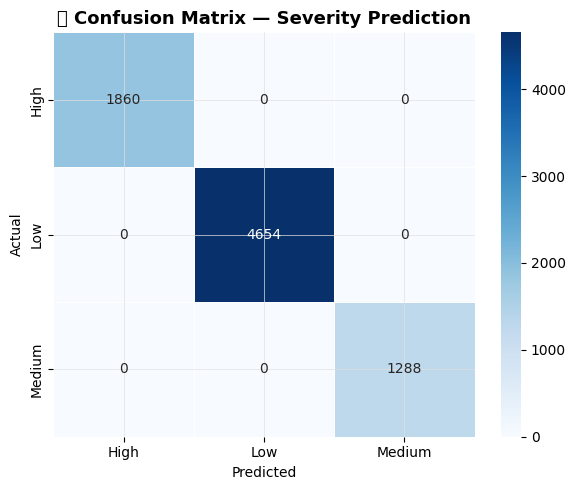

In [ ]:
# ── Confusion Matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_,
    linewidths=0.5, linecolor='white', ax=ax
)
ax.set_title('🎯 Confusion Matrix — Severity Prediction', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

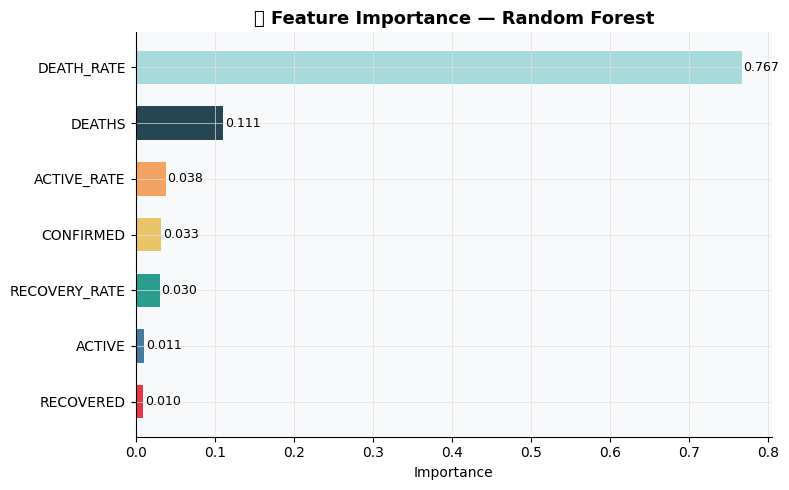

In [ ]:
# ── Feature Importance ─────────────────────────────────────────────────────
importances = pd.Series(model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(importances.index, importances.values,
               color=[PALETTE[i % len(PALETTE)] for i in range(len(importances))],
               edgecolor='none', height=0.6)

for bar in bars:
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.3f}', va='center', fontsize=9)

ax.set_title('🔑 Feature Importance — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 🏁 Step 8 — Conclusion

This notebook covered end-to-end analysis of the COVID-19 Country-wise dataset:

| Section | What we did |
|---|---|
| Data Cleaning | Standardised columns, handled missing values, derived active/recovered if absent |
| Feature Engineering | Computed death rate, recovery rate, active rate, severity labels |
| Visualisations | 6 charts — bar charts, grouped bars, pie, scatter (log), region analysis |
| Key Insights | Global summary statistics and country-level extremes |
| Machine Learning | Random Forest classifier to predict country severity (Low/Medium/High) |

### Possible Extensions
- Add time-series analysis using the `full_grouped.csv` file from the same Kaggle dataset
- Build a choropleth world map using `geopandas` or `plotly`
- Add population data to compute cases per million
- Try other classifiers (Gradient Boosting, SVM) and compare accuracy